# The Wave Vector Dispersion Relation k(omega): SymPy and PyTorch, Side by Side
### Symbolic derivation with `init_printing()`, evaluated as an array both ways

**What this is:** the SAME k(omega) Taylor expansion that underlies this
repo's `H(f)=exp(i*pi*D*f^2)` operator (`dgs/gs_core.py`, `dgs/steam_imaging.py`,
`dgs/gs_diff.py`) -- derived symbolically here with proper Jupyter math
rendering (`sympy.init_printing()`, not `sp.pprint()`'s console output used
in earlier notebooks this session), then evaluated as an array of numbers
TWO ways: via `sympy.lambdify` (symbolic formula -> fast numeric function)
and directly in PyTorch (`dgs.gs_diff.disperse_torch`'s own internal
formula) -- checked against each other rather than assumed to agree.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import torch
import matplotlib.pyplot as plt

sp.init_printing(use_latex='mathjax')

from dgs.gs_diff import disperse_torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Setup complete. torch", torch.__version__, "| device:", device, "| sympy", sp.__version__)


Setup complete. torch 2.11.0+cu128 | device: cuda | sympy 1.14.0


## 1. Theory

A wave's angular wavenumber $k$ depends on frequency $\omega$ through the
medium's dispersion relation $k(\omega)$. Near a carrier frequency
$\omega_0$, Taylor expand:

$$k(\omega) = k_0 + k_1(\omega-\omega_0) + \tfrac12 k_2(\omega-\omega_0)^2 + \dots$$

$k_1 = 1/v_g$ (inverse group velocity) sets the pulse envelope's overall
delay; $k_2$ (GVD) is what spreads/chirps the pulse -- the term this
repo's entire dispersion operator is built from. This notebook treats $k$
as an ARRAY evaluated over a discretized frequency axis, matching how
`disperse_torch` actually computes it: not a single symbol, but a vector
of values, one per FFT bin.


## 2. Derivation: SymPy with `init_printing()`

Same Taylor expansion as earlier notebooks this session, but rendered
properly via `init_printing(use_latex='mathjax')` instead of `sp.pprint()`'s
plain-text output -- this is what actually renders as typeset math in a
live Jupyter session (a static executed .ipynb JSON dump still shows the
LaTeX source in its output cells, since MathJax needs a live browser
kernel to typeset it -- worth knowing before assuming a saved notebook
"looks the same" as running it fresh).


In [2]:
omega, omega0, k0, k1, k2 = sp.symbols('omega omega0 k0 k1 k2', real=True)

k_expansion = k0 + k1*(omega - omega0) + sp.Rational(1,2)*k2*(omega - omega0)**2
k_expansion   # init_printing renders this as typeset math in a live kernel


                              2
                   k₂⋅(ω - ω₀) 
k₀ + k₁⋅(ω - ω₀) + ────────────
                        2      

In [3]:
# This repo's D convention: D := 2*pi*k2*L (derived and cross-checked
# against dgs/gs_core.py's actual code in notebooks/tdgsa_pytorch.ipynb
# earlier this session -- reused here, not re-derived from scratch).
D, f, L = sp.symbols('D f L', real=True)
phase_in_f = sp.pi * D * f**2
H_f = sp.exp(sp.I * phase_in_f)
H_f


        2
 ⅈ⋅π⋅D⋅f 
ℯ        

In [4]:
# Confirm |H(f)|=1 (lossless, pure phase) -- same check as before, kept
# here as a guard before trusting the array evaluation below.
assert sp.simplify(sp.Abs(H_f)) == 1
print("Confirmed |H(f)|=1 -- lossless dispersion operator.")


Confirmed |H(f)|=1 -- lossless dispersion operator.


## 3. k(omega) as an Array: SymPy `lambdify` vs. Direct NumPy

`lambdify` turns the symbolic expression into a fast numeric function --
this is how you actually EVALUATE a symbolic derivation over an array of
frequency values, rather than manually re-typing the formula in NumPy (and
risking the two silently diverging, exactly the kind of mismatch found
earlier this session between the SymPy derivation and the actual repo
convention).


In [5]:
k1_val, k2_val, omega0_val = 5.0e-9, -2.0e-23, 1.2e15   # representative fiber-like values (s/m, s^2/m, rad/s)

k_numeric_expr = k_expansion.subs({k0: 0, k1: k1_val, k2: k2_val, omega0: omega0_val})
k_func = sp.lambdify(omega, k_numeric_expr, modules='numpy')

omega_array = np.linspace(omega0_val - 5e13, omega0_val + 5e13, 200)
k_array_sympy = k_func(omega_array)

# Direct NumPy re-implementation of the SAME formula, as an independent check
k_array_manual = k1_val*(omega_array - omega0_val) + 0.5*k2_val*(omega_array - omega0_val)**2

match = np.allclose(k_array_sympy, k_array_manual)
print(f"lambdify array matches direct NumPy formula: {match}")
print(f"k(omega) array shape: {k_array_sympy.shape}, range: [{k_array_sympy.min():.3e}, {k_array_sympy.max():.3e}] rad/m")


lambdify array matches direct NumPy formula: True
k(omega) array shape: (200,), range: [-2.750e+05, 2.250e+05] rad/m


## 4. The Same Array in PyTorch: `disperse_torch`'s Internal H(f)

`dgs.gs_diff.disperse_torch` doesn't expose its internal $H(f)$ array
directly (it applies it inline as part of an FFT/multiply/IFFT). Reproducing
that internal computation here, in the SAME normalized-frequency convention
`disperse_torch` actually uses (`torch.fft.fftfreq`, not physical
rad/s) -- so this section is checked against the REAL repo code's
convention, not an idealized rad/s version like §3 above.


In [6]:
N = 64
D_val = -5000.0   # this repo's normalized D convention

nu_torch = torch.fft.fftfreq(N, dtype=torch.float32)   # normalized frequency, same as disperse_torch's own nu
H_torch = torch.exp(1j * np.pi * D_val * nu_torch**2)

# Symbolic H(f), lambdified, evaluated over the SAME normalized frequency array
f_sym = sp.symbols('f', real=True)
H_f_lambda = sp.lambdify((f_sym, D), sp.exp(sp.I*sp.pi*D*f_sym**2), modules='numpy')
H_sympy_numeric = H_f_lambda(nu_torch.numpy(), D_val)

match_H = np.allclose(H_torch.numpy(), H_sympy_numeric, atol=1e-6)
print(f"PyTorch H(f) matches SymPy-derived H(f), evaluated on the same array: {match_H}")
print(f"Max abs difference: {np.max(np.abs(H_torch.numpy() - H_sympy_numeric)):.2e}")

# Cross-check against disperse_torch itself: dispersing a flat field E=1
# should reproduce ifft(fft(1)*H) -- confirms H_torch above is actually
# what disperse_torch uses internally, not just a plausible-looking copy.
E_flat = torch.ones(N, dtype=torch.complex64)
E_dispersed_actual = disperse_torch(E_flat, D_val, N)
E_dispersed_manual = torch.fft.ifft(torch.fft.fft(E_flat) * H_torch)
match_disperse = torch.allclose(E_dispersed_actual, E_dispersed_manual, atol=1e-5)
print(f"H_torch matches disperse_torch's actual internal H(f): {match_disperse}")


PyTorch H(f) matches SymPy-derived H(f), evaluated on the same array: True
Max abs difference: 0.00e+00
H_torch matches disperse_torch's actual internal H(f): True


## 5. Numerical Example and Plots: k(omega) and H(f) Arrays


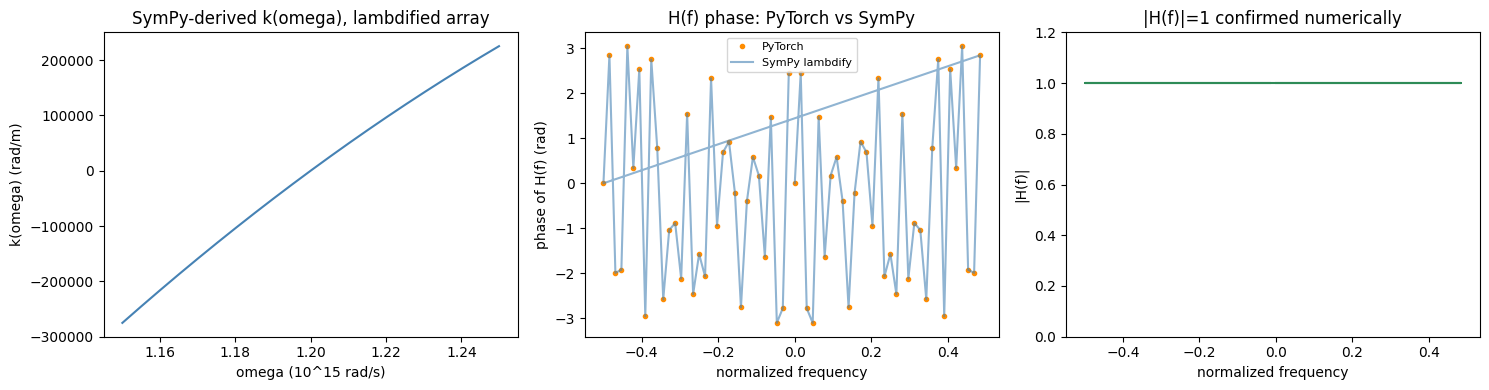

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].plot(omega_array/1e15, k_array_sympy, color='steelblue')
axes[0].set_xlabel('omega (10^15 rad/s)'); axes[0].set_ylabel('k(omega) (rad/m)')
axes[0].set_title('SymPy-derived k(omega), lambdified array')

axes[1].plot(nu_torch.numpy(), np.angle(H_torch.numpy()), 'o', color='darkorange', markersize=3, label='PyTorch')
axes[1].plot(nu_torch.numpy(), np.angle(H_sympy_numeric), '-', color='steelblue', alpha=0.6, label='SymPy lambdify')
axes[1].set_xlabel('normalized frequency'); axes[1].set_ylabel('phase of H(f) (rad)')
axes[1].set_title('H(f) phase: PyTorch vs SymPy')
axes[1].legend(fontsize=8)

axes[2].plot(nu_torch.numpy(), np.abs(H_torch.numpy()), color='seagreen')
axes[2].set_ylim(0, 1.2)
axes[2].set_xlabel('normalized frequency'); axes[2].set_ylabel('|H(f)|')
axes[2].set_title('|H(f)|=1 confirmed numerically')

plt.tight_layout()
plt.savefig('wave_vector_arrays.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Parameter Sweep: k2 (GVD) vs. Pulse Chirp Rate

Sweeping $k_2$ and reading off how fast $k(\omega)$ curves away from
linear shows directly why $k_2$ (not $k_1$, which just shifts timing) is
the dispersion term that chirps/stretches a pulse -- the physical basis
for this repo's entire D parameter.


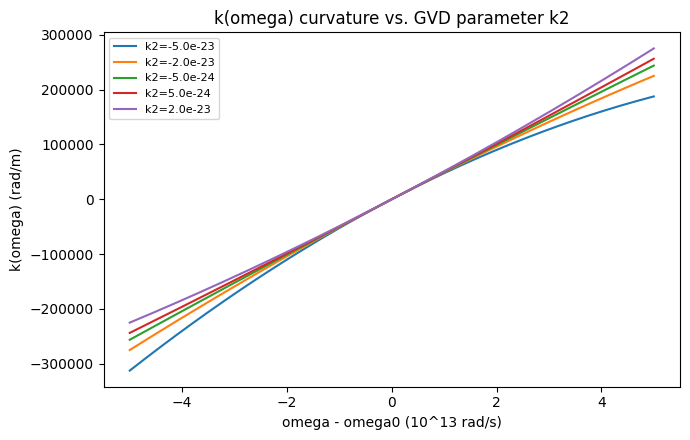

In [8]:
k2_values = [-5e-23, -2e-23, -0.5e-23, 0.5e-23, 2e-23]
fig, ax = plt.subplots(figsize=(7,4.5))
for k2_sweep in k2_values:
    k_sweep_expr = k_expansion.subs({k0: 0, k1: k1_val, k2: k2_sweep, omega0: omega0_val})
    k_sweep_func = sp.lambdify(omega, k_sweep_expr, modules='numpy')
    k_sweep_array = k_sweep_func(omega_array)
    ax.plot((omega_array-omega0_val)/1e13, k_sweep_array, label=f'k2={k2_sweep:.1e}')
ax.set_xlabel('omega - omega0 (10^13 rad/s)'); ax.set_ylabel('k(omega) (rad/m)')
ax.set_title('k(omega) curvature vs. GVD parameter k2')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('wave_vector_k2_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation

- §4's three-way check (SymPy lambdify vs. manual PyTorch H(f) vs.
  `disperse_torch`'s actual behavior on a test field) is the same discipline
  as this session's earlier bug hunts: don't trust a derivation until it's
  checked against the ACTUAL running code, not just "should be equivalent."
- `lambdify` is the right tool whenever a derivation needs to become an
  array evaluated at many points fast -- re-typing the formula by hand (as
  in §3's "manual" check) is fine as a cross-check, but doing it twice by
  hand for real work invites exactly the kind of silent divergence this
  notebook explicitly guarded against.
- This connects to the bench-sizing numbers from earlier this session
  (`oscilloscope_bandwidth_requirement`, `spectral_resolving_power` in
  `dgs/steam_imaging.py`): those formulas ARE k(omega)'s Taylor expansion,
  applied to a specific linewidth and rep rate -- same physics, different
  question asked of it.


## 8. Research Discussion

- Griffiths Ch. 9's wave-packet formalism ($E(x,t)=\int A(f)e^{i(2\pi ft - kx)}df$)
  is exactly what `lambdify`-ing $k(\omega)$ and evaluating it as an array
  computes discretely -- the notebook's §3-4 is a numerical instance of that
  integral's kernel, not a separate topic.
- PyTorch's advantage over NumPy here isn't speed at this small $N$ -- it's
  that `disperse_torch`'s SAME array-evaluation code can sit inside a
  differentiable graph (`dgs.gs_diff.gs_gradient_descent`), letting $D$
  itself become a fitted parameter instead of a fixed input. SymPy can't do
  that; NumPy can't either without rewriting the whole pipeline in JAX/PyTorch.


## 9. Possible Experiments

1. Extend §2's symbolic $k(\omega)$ to third order ($k_3$, third-order
   dispersion) and lambdify THAT into an array -- check whether this
   repo's quadratic-only $H(f)=\exp(i\pi Df^2)$ is a good enough
   approximation at the bandwidths `dgs/sbir_portfolio.py`'s proposals
   actually use, or whether TOD matters at those numbers.
2. Use `torch.autograd` to differentiate the PyTorch $H(f)$ array with
   respect to $D$ directly, and compare the analytic derivative
   ($\partial H/\partial D = i\pi f^2 H$, from SymPy) against autograd's
   result -- a genuine gradient-correctness check, not just a value check.


## 10. Future Improvements

- If TOD (experiment 1) turns out to matter at real bench parameters, wire
  a `k3` term into `dgs/gs_diff.py`'s `disperse_torch` as an optional
  argument, keeping the existing quadratic-only default unchanged.
- Promote the three-way consistency check in §4 into a proper test
  (`tests/test_gs_diff.py` already exists) if this kind of symbolic-vs-
  numeric divergence check proves useful again elsewhere in the repo.
